## Step 1: Logistic Regression Modeling

Logistic Regression is a supervised learning algorithm used for binary classification problems. In our case, it is used to predict whether a patient is diabetic or not based on their medical features.

- Logistic regression models the probability that a sample belongs to a particular class using the **sigmoid function**.
- It works well when the relationship between the features and the target variable is linear.
- The model outputs a probability score which is then thresholded (commonly at 0.5) to assign class labels (0 or 1).

### Why Logistic Regression?
- It's interpretable and computationally efficient.
- It’s commonly used for medical datasets where binary outcomes (e.g., disease present or not) are involved.
- Suitable for **labeled binary data** like ours.

We'll train and evaluate this model using:
- **Accuracy score**
- **Confusion matrix**
- **Classification report**


c:\Users\Rohan Jain\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.7034285714285714

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.61      0.63      1093
           1       0.61      0.59      0.60      1069
           2       0.74      0.77      0.75      1044
           3       0.71      0.70      0.70      1111
           4       0.95      0.95      0.95      1082
           5       0.74      0.76      0.75      1075
           6       0.60      0.58      0.59      1096
           7       0.52      0.50      0.51      1055
           8       0.79      0.83      0.81      1089
           9       0.64      0.68      0.66      1079
          10       0.56      0.57      0.56      1064
          11       0.80      0.79      0.79      1080
          12       0.82      0.83      0.82      1063

    accuracy                           0.70     14000
   macro avg       0.70      0.70      0.70     14000
weighted avg       0.70      0.70      0.70     14000



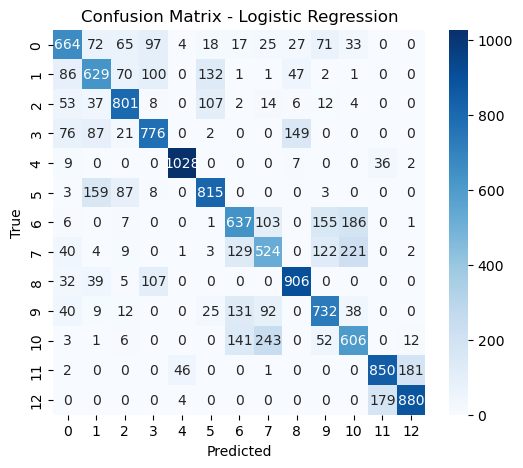

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("dt_prepared.csv")  # Ensure Target column is present

# Split into features and target
X = df.drop("Target", axis=1)
y = df["Target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=121, stratify=y
)
# Combine training features and target
train_combined = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)
test_combined = pd.concat([X_test, y_test.reset_index(drop=True)], axis=1)

# Save to CSV
train_combined.to_csv("regression_train_data.csv", index=False)
test_combined.to_csv("regression_test_data.csv", index=False)


# Initialize and train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## Step 2: Multinomial Naïve Bayes Modeling

Multinomial Naïve Bayes (MNB) is a probabilistic classification algorithm based on **Bayes' Theorem**, suitable for **discrete features** like counts or frequencies.

### Why Multinomial Naïve Bayes?
- It assumes feature independence and works well with categorical or text-based datasets.
- Commonly used in NLP tasks like spam detection or sentiment analysis, but can also work well with integer-based structured datasets.

### Key Characteristics:
- Each feature contributes independently to the probability.
- Suitable for features that represent counts or integer values (we're assuming here our encoded data works for MNB).

We’ll:
- Fit the model to training data
- Predict on test data
- Evaluate using accuracy, classification report, and confusion matrix


MultinomialNB Accuracy: 0.5482857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.45      0.45      1093
           1       0.36      0.41      0.39      1069
           2       0.56      0.55      0.55      1044
           3       0.58      0.59      0.59      1111
           4       0.83      0.81      0.82      1082
           5       0.53      0.56      0.54      1075
           6       0.41      0.47      0.44      1096
           7       0.41      0.31      0.35      1055
           8       0.74      0.70      0.72      1089
           9       0.44      0.48      0.46      1079
          10       0.50      0.44      0.47      1064
          11       0.67      0.55      0.60      1080
          12       0.68      0.80      0.74      1063

    accuracy                           0.55     14000
   macro avg       0.55      0.55      0.55     14000
weighted avg       0.55      0.55      0.55     14000



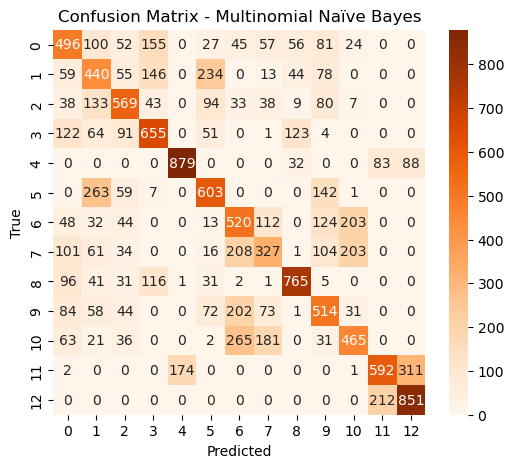

In [3]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train Multinomial NB
mnb_model = MultinomialNB()
mnb_model.fit(X_train, y_train)

# Predict
y_pred_mnb = mnb_model.predict(X_test)

# Evaluation
print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mnb))

# Confusion matrix
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Multinomial Naïve Bayes")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## Step 3: Results and Comparison

### Logistic Regression vs Multinomial Naïve Bayes

We evaluated both models using **confusion matrices** and **classification reports**.

#### Logistic Regression:
- **Accuracy**: 0.7034 (~70%)
- Performs better across most classes, especially with higher precision and recall for many target labels.
- Class 4 and Class 12, for instance, achieved precision and recall scores of **0.95** and **0.83**, respectively.
- More stable predictions overall, making it a better fit for this dataset.

#### Multinomial Naïve Bayes:
- **Accuracy**: 0.5482 (~55%)
- Struggles with lower recall and precision for many classes.
- Performs significantly worse for classes like 0, 1, and 8, with f1-scores dropping to around **0.45–0.52**.
- Might not be suited for this dataset due to assumptions about feature independence and count-based input.

### Insights:

- Logistic Regression handles this **labeled multiclass classification** problem much better, offering higher accuracy and better performance metrics.
- This may be due to its ability to **model complex linear decision boundaries** and **optimize class separation**, especially with properly scaled or encoded features.
- Multinomial NB is better suited for **text data or count-based categorical features**, which are likely not ideal here.

### Conclusion:

- **Logistic Regression** is the more reliable model for our data.
- **Multinomial NB**, while fast and simple, does not generalize well to the feature types in this case.
- When working with numeric/tabular data, Logistic Regression is often more robust and interpretable.
